# Solver solution sanity check

Solve three small MovingAI instances from different map families with LaCAM, improve each solution with MAPF-LNS, validate both solutions, and display every path animation.

In [7]:
from pathlib import Path
import sys

from IPython.display import Markdown, SVG, display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT / "src"))

from mapf_anytime.problem import MapfProblem
from mapf_anytime.solvers import LaCAMConfig, LNSConfig, run_lacam, run_lns
from mapf_anytime.visualizer import visualize

INSTANCE_IDS = [
    "empty-32-32-random-2-density-b1-n23",
    "maze-32-32-2-random-3-density-b1-n20",
    "room-32-32-4-random-13-density-b1-n19",
]
INSTANCE_DIR = ROOT / "datasets" / "movingai" / "instances"
OUTPUT_DIR = ROOT / "notebooks" / "demo_output"


## Solve, validate, and visualize

`MapfSolution.errors` checks path count, start and goal positions, map bounds, obstacles, legal single-step movement, vertex conflicts, and edge-swap conflicts. The notebook stops immediately if either solver returns an invalid solution.

## empty-32-32-random-2-density-b1-n23 (23 agents)

LaCAM valid: SOC=498, makespan=35, wall=0.012s


**LaCAM solution**

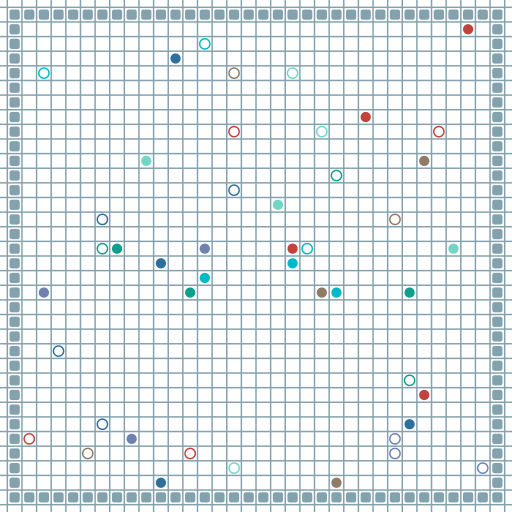

LNS valid: SOC=496, makespan=35, improvement=2, wall=9.907s


**MAPF-LNS solution**

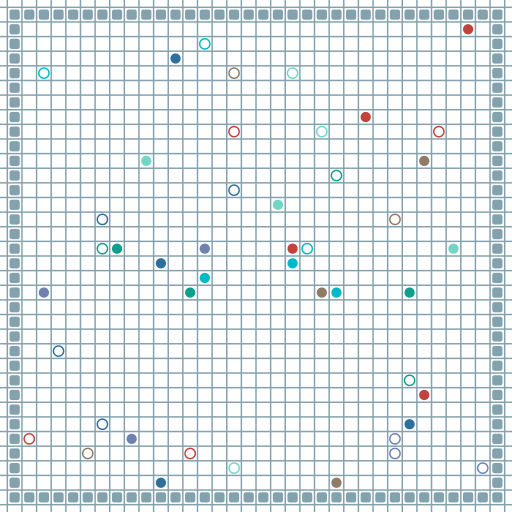

## maze-32-32-2-random-3-density-b1-n20 (20 agents)

LaCAM valid: SOC=1137, makespan=112, wall=0.029s


**LaCAM solution**

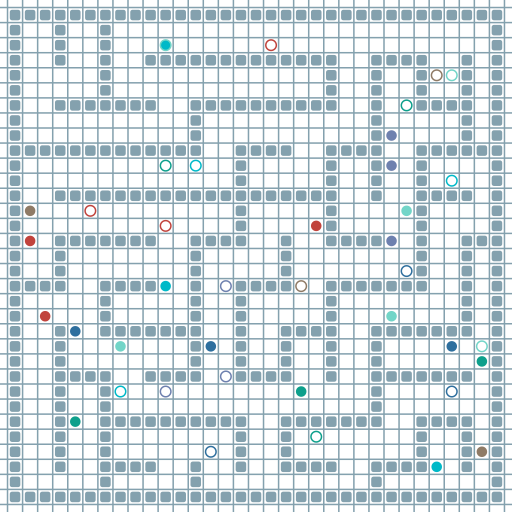

LNS valid: SOC=1084, makespan=112, improvement=53, wall=9.915s


**MAPF-LNS solution**

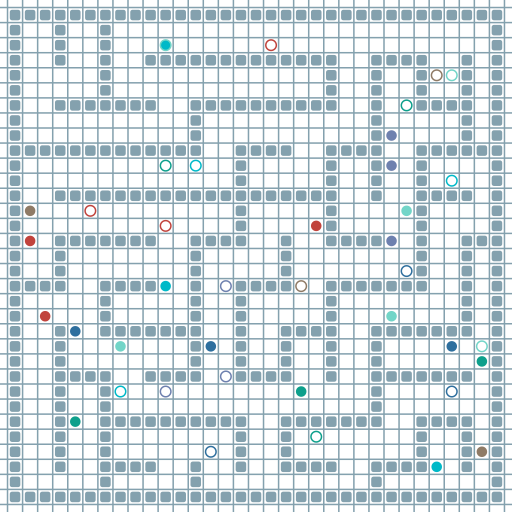

## room-32-32-4-random-13-density-b1-n19 (19 agents)

LaCAM valid: SOC=424, makespan=35, wall=0.007s


**LaCAM solution**

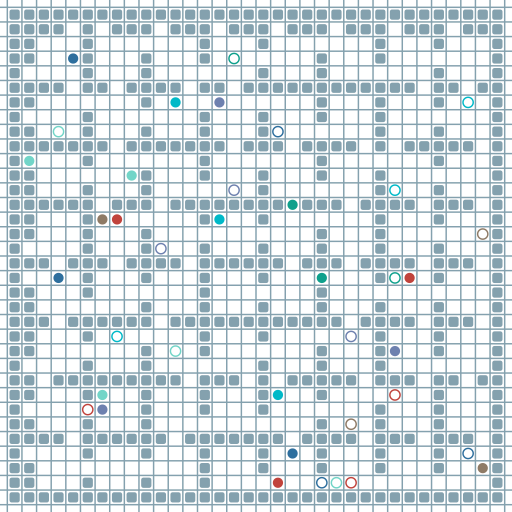

LNS valid: SOC=420, makespan=34, improvement=4, wall=9.862s


**MAPF-LNS solution**

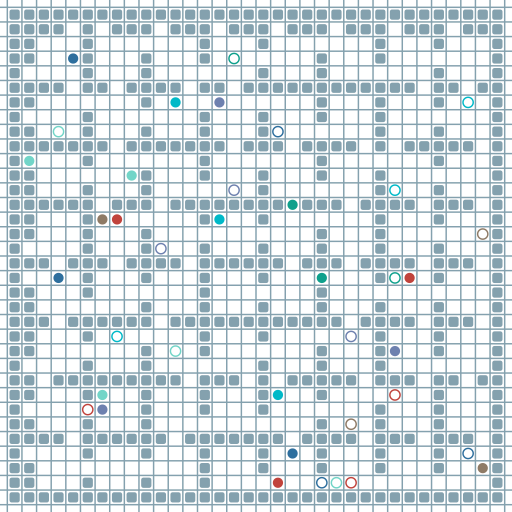

In [8]:
for instance_id in INSTANCE_IDS:
    problem = MapfProblem.from_manifest(INSTANCE_DIR / f"{instance_id}.json")
    display(Markdown(f"## {problem.name} ({problem.agents} agents)"))

    lacam = run_lacam(problem, LaCAMConfig(timeout=10, seed=0))
    if lacam.solution is None:
        raise RuntimeError(f"{problem.name}: LaCAM failed: {lacam.error or lacam.status}")
    lacam_errors = lacam.solution.errors(problem)
    assert not lacam_errors, f"{problem.name}: invalid LaCAM solution: {lacam_errors}"
    print(
        f"LaCAM valid: SOC={lacam.solution.soc()}, "
        f"makespan={lacam.solution.makespan()}, wall={lacam.wall_seconds:.3f}s"
    )
    lacam_svg = visualize(problem, lacam.solution, OUTPUT_DIR / f"{instance_id}_lacam.svg")
    display(Markdown("**LaCAM solution**"), SVG(filename=str(lacam_svg)))

    lns = run_lns(
        problem,
        lacam.solution,
        LNSConfig(timeout=10, seed=1, neighborhood_size=4, replan_time_limit=10),
    )
    if lns.solution is None:
        raise RuntimeError(f"{problem.name}: LNS failed: {lns.error or lns.stderr_tail or lns.status}")
    lns_errors = lns.solution.errors(problem)
    assert not lns_errors, f"{problem.name}: invalid LNS solution: {lns_errors}"
    print(
        f"LNS valid: SOC={lns.solution.soc()}, makespan={lns.solution.makespan()}, "
        f"improvement={lacam.solution.soc() - lns.solution.soc()}, wall={lns.wall_seconds:.3f}s"
    )
    lns_svg = visualize(problem, lns.solution, OUTPUT_DIR / f"{instance_id}_lns.svg")
    display(Markdown("**MAPF-LNS solution**"), SVG(filename=str(lns_svg)))
